In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
START_DATE = "2016-01-01"
END_DATE = "2026-01-01"
print(f"Data period: {START_DATE} to {END_DATE}")

Data period: 2016-01-01 to 2026-01-01


In [3]:
# load historical S&P 500 membership data

historical_url = (
    "https://raw.githubusercontent.com/"
    "fja05680/sp500/master/"
    "S%26P%20500%20Historical%20Components%20%26%20Changes%20%28Updated%29.csv"
)

historical_sp500 = pd.read_csv(historical_url)

historical_sp500.head()

,date,tickers
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."


In [4]:
historical_sp500["date"] = pd.to_datetime(historical_sp500["date"])

print("Historical data:")
print(historical_sp500["date"].min(), "to", historical_sp500["date"].max())

Historical data:
1996-01-02 00:00:00 to 2026-06-30 00:00:00


In [5]:
historical_sp500 = historical_sp500[
    (historical_sp500["date"] >= START_DATE) &
    (historical_sp500["date"] < END_DATE)
].copy()

print("Research period:")
print(historical_sp500["date"].min(), "to", historical_sp500["date"].max())


Research period:
2016-01-04 00:00:00 to 2025-12-22 00:00:00


In [6]:
# one row for each stock on membership date

historical_sp500["Ticker"] = historical_sp500["tickers"].str.split(",")

membership = historical_sp500[["date", "Ticker"]].explode("Ticker")

membership = membership.reset_index(drop=True)

membership.head()

,date,Ticker
0,2016-01-04,A
1,2016-01-04,AABA
2,2016-01-04,AAL
3,2016-01-04,AAP
4,2016-01-04,AAPL


In [7]:
print("Research period:")
print(membership["date"].min(), "to", membership["date"].max())

print("\nUnique historical tickers:")
print(membership["Ticker"].nunique())

print("\nAverage constituents per date:")
print(membership.groupby("date")["Ticker"].nunique().mean())

Research period:
2016-01-04 00:00:00 to 2025-12-22 00:00:00

Unique historical tickers:
728

Average constituents per date:
505.2421052631579


In [8]:
tickers = sorted(membership["Ticker"].unique())

print(f"Total unique historical tickers: {len(tickers)}")
print(tickers[:25])

Total unique historical tickers: 728
['A', 'AABA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABMD', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'ADT', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AGN']


In [9]:
# Download historical stock data in batches so that it doesnt crash

all_data = {}
failed_tickers = []

batch_size = 50

for i in range(0, len(tickers), batch_size):

    batch = tickers[i:i + batch_size]

    print(f"Downloading {i + 1}-{min(i + batch_size, len(tickers))} "
          f"of {len(tickers)}...")

    data = yf.download(
        batch,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        group_by="ticker",
        progress=False,
        threads=True
    )

    for ticker in batch:

        if ticker in data.columns.get_level_values(0):

            ticker_data = data[ticker].dropna(how="all")

            if not ticker_data.empty:
                all_data[ticker] = ticker_data
            else:
                failed_tickers.append(ticker)

        else:
            failed_tickers.append(ticker)

print("\nDownload complete!")
print("Usable tickers:", len(all_data))
print("Unavailable tickers:", len(failed_tickers))

$AABA: possibly delisted; no timezone found
$AGN: possibly delisted; no timezone found
$ADS: possibly delisted; no timezone found
$ALXN: possibly delisted; no timezone found
$ABC: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found
$ABMD: possibly delisted; no timezone found

7 Failed downloads:
['AABA', 'AGN', 'ADS', 'ALXN', 'ABC', 'ANSS', 'ABMD']: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)


$BRCM: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$BK: possibly delisted; no timezone found
$ARNC: possibly delisted; no timezone found
$ANTM: possibly delisted; no timezone found
$BCR: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$ATVI: possibly delisted; no timezone found
$BBBY: Data doesn't exist for startDate = 1451624400, endDate = 1767243600
$ARG: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$APC: Data doesn't exist for startDate = 1451624400, endDate = 1767243600
$BLL: possibly delisted; no timezone found
$BHGE: possibly delisted; no timezone found
$AVB: Data doesn't exist for startDate = 1451624400, endDate = 1767243600

13 Failed downloads:
['BF.B', 'BRCM', 'BCR', 'ARG']: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
['BK', 'ARNC', 'ANTM', 'ATVI', 'BLL', 'BHGE']: possibly delisted; no timezone found
['BBBY', 'APC', 'AVB']: Data doesn't exist for startDate = 1451624400, endDate 

$CELG: possibly delisted; no timezone found
$CA: possibly delisted; no timezone found
$BXLT: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$CHK: possibly delisted; no timezone found
$CBS: possibly delisted; no timezone found
$CERN: possibly delisted; no timezone found
$COG: possibly delisted; no timezone found
$BRK.B: possibly delisted; no timezone found
$CMA: possibly delisted; no timezone found
$CDAY: possibly delisted; no timezone found

10 Failed downloads:
['CELG', 'CA', 'CHK', 'CBS', 'CERN', 'COG', 'BRK.B', 'CMA', 'CDAY']: possibly delisted; no timezone found
['BXLT']: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)


$CTL: possibly delisted; no timezone found
$CPGX: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$CTRA: possibly delisted; no timezone found
$CXO: possibly delisted; no timezone found
$DAY: possibly delisted; no timezone found
$CTXS: possibly delisted; no timezone found
$CSRA: Data doesn't exist for startDate = 1451624400, endDate = 1767243600
$CTLT: possibly delisted; no timezone found
$DFS: possibly delisted; no timezone found
$DISCA: possibly delisted; no timezone found
$CVC: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)

11 Failed downloads:
['CTL', 'CTRA', 'CXO', 'DAY', 'CTXS', 'CTLT', 'DFS', 'DISCA']: possibly delisted; no timezone found
['CPGX', 'CVC']: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
['CSRA']: Data doesn't exist for startDate = 1451624400, endDate = 1767243600


$ETFC: possibly delisted; no timezone found
$ENDP: possibly delisted; no timezone found
$DWDP: possibly delisted; no timezone found
$DO: possibly delisted; no timezone found
$DRE: possibly delisted; no timezone found
$ESV: possibly delisted; no timezone found
$DNB: possibly delisted; no timezone found
$DISH: possibly delisted; no timezone found
$EA: Data doesn't exist for startDate = 1451624400, endDate = 1767243600
$EQR: Data doesn't exist for startDate = 1451624400, endDate = 1767243600
$DISCK: possibly delisted; no timezone found

11 Failed downloads:
['ETFC', 'ENDP', 'DWDP', 'DO', 'DRE', 'ESV', 'DNB', 'DISH', 'DISCK']: possibly delisted; no timezone found
['EA', 'EQR']: Data doesn't exist for startDate = 1451624400, endDate = 1767243600


...

$SPLS: Data doesn't exist for startDate = 1451624400, endDate = 1767243600
$RHT: possibly delisted; no timezone found
$RAI: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$SIVB: possibly delisted; no timezone found
$RTN: possibly delisted; no timezone found
$SEE: possibly delisted; no timezone found
$SNI: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$RE: possibly delisted; no timezone found
$SRCL: possibly delisted; no timezone found

9 Failed downloads:
['SPLS']: Data doesn't exist for startDate = 1451624400, endDate = 1767243600
['RHT', 'SIVB', 'RTN', 'SEE', 'RE', 'SRCL']: possibly delisted; no timezone found
['RAI', 'SNI']: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)


$TIF: possibly delisted; no timezone found
$STJ: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$TGNA: possibly delisted; no timezone found
$TMK: possibly delisted; no timezone found
$SYMC: possibly delisted; no timezone found
$SWN: possibly delisted; no timezone found
$TSS: possibly delisted; no timezone found

7 Failed downloads:
['TIF', 'TGNA', 'TMK', 'SYMC', 'SWN', 'TSS']: possibly delisted; no timezone found
['STJ']: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)


$VIAC: possibly delisted; no timezone found
$UTX: possibly delisted; no timezone found
$WBA: possibly delisted; no timezone found
$VAR: possibly delisted; no timezone found
$WFM: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$WCG: possibly delisted; no timezone found
$TWTR: possibly delisted; no timezone found
$TWC: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)
$VIAB: possibly delisted; no timezone found

9 Failed downloads:
['VIAC', 'UTX', 'WBA', 'VAR', 'WCG', 'TWTR', 'VIAB']: possibly delisted; no timezone found
['WFM', 'TWC']: possibly delisted; no price data found  (1d 2016-01-01 -> 2026-01-01)


$WRK: possibly delisted; no timezone found
$XEC: possibly delisted; no timezone found
$XLNX: possibly delisted; no timezone found
$WLTW: possibly delisted; no timezone found
$XL: possibly delisted; no timezone found
$WYND: possibly delisted; no timezone found

6 Failed downloads:
['WRK', 'XEC', 'XLNX', 'WLTW', 'XL', 'WYND']: possibly delisted; no timezone found



Download complete!
Usable tickers: 599
Unavailable tickers: 129


In [10]:
print("Total historical tickers:", len(tickers))
print("Usable tickers:", len(all_data))
print("Unavailable tickers:", len(failed_tickers))

print("\nExample usable tickers:")
print(list(all_data.keys())[:20])

Total historical tickers: 728
Usable tickers: 599
Unavailable tickers: 129

Example usable tickers:
['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'ADT', 'AEE', 'AEP', 'AES', 'AET', 'AFL']


In [11]:
# check how much historical data we have for each ticker

data_summary = []

for ticker, data in all_data.items():
    data_summary.append({
        "Ticker": ticker,
        "Start": data.index.min(),
        "End": data.index.max(),
        "Rows": len(data)
    })

data_summary = pd.DataFrame(data_summary)

data_summary.head()

,Ticker,Start,End,Rows
0,A,2016-01-04,2025-12-31,2514
1,AAL,2016-01-04,2025-12-31,2514
2,AAP,2016-01-04,2025-12-31,2514
3,AAPL,2016-01-04,2025-12-31,2514
4,ABBV,2016-01-04,2025-12-31,2514


In [12]:
print(data_summary["Rows"].describe())

count     599.000000
mean     2372.833055
std       474.481328
min        46.000000
25%      2514.000000
50%      2514.000000
75%      2514.000000
max      2514.000000
Name: Rows, dtype: float64


In [13]:
data_summary.sort_values("Rows").head(20)

,Ticker,Start,End,Rows
451,Q,2025-10-27,2025-12-31,46
489,SOLS,2025-10-20,2025-12-31,51
438,POM,2025-10-08,2025-12-31,59
88,CAM,2025-10-06,2025-12-31,61
420,PCL,2025-08-05,2025-12-31,104
207,FB,2025-06-26,2025-12-31,131
94,CCE,2019-02-27,2020-04-29,138
486,SNDK,2025-02-13,2025-12-31,222
262,HOT,2016-01-04,2017-03-20,300
282,INFO,2024-10-10,2025-12-31,307


In [14]:
# lookup of historical S&P 500 membership

membership["date"] = pd.to_datetime(membership["date"])
membership["Ticker"] = membership["Ticker"].str.strip()

membership_lookup = membership.copy()

membership_lookup.head()

,date,Ticker
0,2016-01-04,A
1,2016-01-04,AABA
2,2016-01-04,AAL
3,2016-01-04,AAP
4,2016-01-04,AAPL


In [15]:
print("Membership rows:", len(membership_lookup))
print("Unique dates:", membership_lookup["date"].nunique())
print("Unique tickers:", membership_lookup["Ticker"].nunique())

Membership rows: 239990
Unique dates: 475
Unique tickers: 728


In [16]:
# features for every usable stock

stock_features = []

for ticker, data in all_data.items():

    df = data.copy()

    # daily return
    df["Return"] = df["Close"].pct_change()

    # previous-day return
    df["Previous_Return"] = df["Return"].shift(1)

    # multi-day returns
    df["Return_5D"] = df["Close"].pct_change(5)
    df["Return_10D"] = df["Close"].pct_change(10)
    df["Return_20D"] = df["Close"].pct_change(20)

    # 20-day volatility
    df["Volatility_20D"] = df["Return"].rolling(20).std()

    # moving averages
    df["MA_5"] = df["Close"].rolling(5).mean()
    df["MA_20"] = df["Close"].rolling(20).mean()

    # momentum
    df["Momentum_20D"] = (
        df["Close"] / df["Close"].shift(20) - 1
    )

    # volume change
    df["Volume_Change"] = df["Volume"].pct_change()

    # price relative to MA20
    df["Price_to_MA20"] = (
        df["Close"] / df["MA_20"]
    )

    # next-day return
    df["Next_Day_Return"] = df["Return"].shift(-1)

    # add ticker
    df["Ticker"] = ticker

    # move date from index into a column
    df = df.reset_index()

    stock_features.append(df)

print("Stocks processed:", len(stock_features))

Stocks processed: 599


In [17]:
# combine all stocks into one dataset

stock_data = pd.concat(
    stock_features,
    ignore_index=True
)

print("Shape:", stock_data.shape)
stock_data.head()

Shape: (1421327, 19)


Price,Date,Open,High,Low,Close,Volume,Return,Previous_Return,Return_5D,Return_10D,Return_20D,Volatility_20D,MA_5,MA_20,Momentum_20D,Volume_Change,Price_to_MA20,Next_Day_Return,Ticker
0,2016-01-04,37.751921,37.871444,37.089928,37.411728,3287300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003441,A
1,2016-01-05,37.448511,37.650787,37.089932,37.283012,2587200.0,-0.003441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.212971,NaN,0.004439,A
2,2016-01-06,36.997993,37.687568,36.823298,37.448513,2103600.0,0.004439,-0.003441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.186920,NaN,-0.042475,A
3,2016-01-07,36.906048,36.915244,35.683204,35.857895,3504300.0,-0.042475,0.004439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.665859,NaN,-0.010513,A
4,2016-01-08,36.060170,36.510691,35.370596,35.480927,3736700.0,-0.010513,-0.042475,NaN,NaN,NaN,NaN,36.696415,NaN,NaN,0.066319,NaN,-0.016844,A


In [18]:
# download S&P 500 market data

sp500_data = yf.download(
    "^GSPC",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

# calculate daily market return
sp500_data["Market_Return"] = sp500_data["Close"].pct_change()

print("S&P 500 data shape:", sp500_data.shape)
sp500_data.head()

S&P 500 data shape: (2514, 6)


Price,Close,High,Low,Open,Volume,Market_Return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,
2016-01-04,2012.660034,2038.199951,1989.680054,2038.199951,4304880000,NaN
2016-01-05,2016.709961,2021.939941,2004.170044,2013.780029,3706620000,0.002012
2016-01-06,1990.260010,2011.709961,1979.050049,2011.709961,4336660000,-0.013115
2016-01-07,1943.089966,1985.319946,1938.829956,1985.319946,5076590000,-0.023700
2016-01-08,1922.030029,1960.400024,1918.459961,1945.969971,4664940000,-0.010838


In [19]:
# S&P 500 market return

market_data = sp500_data.copy()

market_data = market_data.reset_index()

if isinstance(market_data.columns, pd.MultiIndex):
    market_data.columns = market_data.columns.get_level_values(0)

market_data = market_data[["Date", "Market_Return"]].copy()

market_data["Date"] = pd.to_datetime(market_data["Date"])

market_data.head()

Price,Date,Market_Return
0,2016-01-04,NaN
1,2016-01-05,0.002012
2,2016-01-06,-0.013115
3,2016-01-07,-0.023700
4,2016-01-08,-0.010838


In [20]:
# combine all stock features into one dataset

stock_data = pd.concat(
    stock_features,
    ignore_index=True
)

print("Shape:", stock_data.shape)
print("Number of stocks:", stock_data["Ticker"].nunique())

stock_data.head()

Shape: (1421327, 19)
Number of stocks: 599


Price,Date,Open,High,Low,Close,Volume,Return,Previous_Return,Return_5D,Return_10D,Return_20D,Volatility_20D,MA_5,MA_20,Momentum_20D,Volume_Change,Price_to_MA20,Next_Day_Return,Ticker
0,2016-01-04,37.751921,37.871444,37.089928,37.411728,3287300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003441,A
1,2016-01-05,37.448511,37.650787,37.089932,37.283012,2587200.0,-0.003441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.212971,NaN,0.004439,A
2,2016-01-06,36.997993,37.687568,36.823298,37.448513,2103600.0,0.004439,-0.003441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.186920,NaN,-0.042475,A
3,2016-01-07,36.906048,36.915244,35.683204,35.857895,3504300.0,-0.042475,0.004439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.665859,NaN,-0.010513,A
4,2016-01-08,36.060170,36.510691,35.370596,35.480927,3736700.0,-0.010513,-0.042475,NaN,NaN,NaN,NaN,36.696415,NaN,NaN,0.066319,NaN,-0.016844,A


In [21]:
stock_data["Date"] = pd.to_datetime(stock_data["Date"])

print(stock_data["Date"].min())
print(stock_data["Date"].max())

2016-01-04 00:00:00
2025-12-31 00:00:00


In [22]:
# add S&P 500 market return to each stock-day observation

stock_data = stock_data.merge(
    market_data,
    on="Date",
    how="left"
)

print("Shape:", stock_data.shape)

stock_data.head()

Shape: (1421327, 20)


Price,Date,Open,High,Low,Close,Volume,Return,Previous_Return,Return_5D,Return_10D,Return_20D,Volatility_20D,MA_5,MA_20,Momentum_20D,Volume_Change,Price_to_MA20,Next_Day_Return,Ticker,Market_Return
0,2016-01-04,37.751921,37.871444,37.089928,37.411728,3287300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003441,A,NaN
1,2016-01-05,37.448511,37.650787,37.089932,37.283012,2587200.0,-0.003441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.212971,NaN,0.004439,A,0.002012
2,2016-01-06,36.997993,37.687568,36.823298,37.448513,2103600.0,0.004439,-0.003441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.186920,NaN,-0.042475,A,-0.013115
3,2016-01-07,36.906048,36.915244,35.683204,35.857895,3504300.0,-0.042475,0.004439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.665859,NaN,-0.010513,A,-0.023700
4,2016-01-08,36.060170,36.510691,35.370596,35.480927,3736700.0,-0.010513,-0.042475,NaN,NaN,NaN,NaN,36.696415,NaN,NaN,0.066319,NaN,-0.016844,A,-0.010838


In [24]:
# clean historical S&P 500 membership data

membership_clean = membership.copy()

membership_clean["Date"] = pd.to_datetime(membership_clean["date"])
membership_clean["Ticker"] = membership_clean["Ticker"].str.strip()

membership_clean = membership_clean[["Date", "Ticker"]]

print("Membership observations:", len(membership_clean))
print("Unique stocks:", membership_clean["Ticker"].nunique())

membership_clean.head()

Membership observations: 239990
Unique stocks: 728


,Date,Ticker
0,2016-01-04,A
1,2016-01-04,AABA
2,2016-01-04,AAL
3,2016-01-04,AAP
4,2016-01-04,AAPL


In [25]:
# create historical S&P 500 membership indicator

membership_indicator = membership_clean.drop_duplicates(
    subset=["Date", "Ticker"]
).copy()

membership_indicator["In_SP500"] = 1

print("Membership observations:", len(membership_indicator))
print("Unique stocks:", membership_indicator["Ticker"].nunique())

membership_indicator.head()

Membership observations: 239990
Unique stocks: 728


,Date,Ticker,In_SP500
0,2016-01-04,A,1
1,2016-01-04,AABA,1
2,2016-01-04,AAL,1
3,2016-01-04,AAP,1
4,2016-01-04,AAPL,1


In [30]:
print(stock_data.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Previous_Return', 'Return_5D', 'Return_10D', 'Return_20D', 'Volatility_20D', 'MA_5', 'MA_20', 'Momentum_20D', 'Volume_Change', 'Price_to_MA20', 'Next_Day_Return', 'Ticker', 'Market_Return']


In [31]:
# create historical S&P 500 membership indicator

membership_indicator = membership_clean.drop_duplicates(
    subset=["Date", "Ticker"]
).copy()

membership_indicator["In_SP500"] = 1

print("Membership observations:", len(membership_indicator))
print("Unique stocks:", membership_indicator["Ticker"].nunique())

membership_indicator.head()

Membership observations: 239990
Unique stocks: 728


,Date,Ticker,In_SP500
0,2016-01-04,A,1
1,2016-01-04,AABA,1
2,2016-01-04,AAL,1
3,2016-01-04,AAP,1
4,2016-01-04,AAPL,1


In [32]:
# add historical S&P 500 membership to stock data

stock_data = stock_data.merge(
    membership_indicator,
    on=["Date", "Ticker"],
    how="left"
)

stock_data["In_SP500"] = stock_data["In_SP500"].fillna(0)

print("Stock data shape:", stock_data.shape)
print(stock_data["In_SP500"].value_counts())

Stock data shape: (1421327, 21)
In_SP500
0.0    1222916
1.0     198411
Name: count, dtype: int64


In [33]:
# create historical S&P 500 dataset

historical_data = stock_data[
    stock_data["In_SP500"] == 1
].copy()

print("Historical S&P 500 dataset shape:", historical_data.shape)
print("Unique stocks:", historical_data["Ticker"].nunique())
print(
    "Date range:",
    historical_data["Date"].min(),
    "to",
    historical_data["Date"].max()
)

Historical S&P 500 dataset shape: (198411, 21)
Unique stocks: 586
Date range: 2016-01-04 00:00:00 to 2025-12-22 00:00:00


In [34]:
# historical S&P 500 data for modeling

model_data = historical_data.copy()

features = [
    "Previous_Return",
    "Return_5D",
    "Return_10D",
    "Return_20D",
    "Volatility_20D",
    "MA_5",
    "MA_20",
    "Momentum_20D",
    "Volume_Change",
    "Price_to_MA20",
    "Market_Return"
]

target = "Next_Day_Return"

# keep only the variables needed for modeling
model_data = model_data[
    ["Date", "Ticker"] + features + [target]
].copy()

# remove rows with missing values
model_data = model_data.dropna()

print("Modeling dataset shape:", model_data.shape)
print("Number of stocks:", model_data["Ticker"].nunique())
print("Date range:", model_data["Date"].min(), "to", model_data["Date"].max())

Modeling dataset shape: (193695, 14)
Number of stocks: 585
Date range: 2016-02-02 00:00:00 to 2025-12-22 00:00:00


In [35]:
# set a fixed time-based train/test split

split_date = pd.Timestamp("2023-01-01")

print("Training period:", model_data["Date"].min(), "to", split_date - pd.Timedelta(days=1))
print("Testing period:", split_date, "to", model_data["Date"].max())

Training period: 2016-02-02 00:00:00 to 2022-12-31 00:00:00
Testing period: 2023-01-01 00:00:00 to 2025-12-22 00:00:00


In [36]:
# create time-based training and testing datasets

train_data = model_data[
    model_data["Date"] < split_date
].copy()

test_data = model_data[
    model_data["Date"] >= split_date
].copy()

# Predictor variables
X_train = train_data[features]
X_test = test_data[features]

# Target variable
y_train = train_data[target]
y_test = test_data[target]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining date range:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTesting date range:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Training observations: 172501
Testing observations: 21194

Training date range:
2016-02-02 00:00:00 to 2022-12-22 00:00:00

Testing date range:
2023-01-04 00:00:00 to 2025-12-22 00:00:00


In [37]:
# Replace infinite values with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Remove any rows containing missing values
train_mask = X_train.notna().all(axis=1)
test_mask = X_test.notna().all(axis=1)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

print("Training shape after cleaning:", X_train.shape)
print("Testing shape after cleaning:", X_test.shape)

Training shape after cleaning: (172432, 11)
Testing shape after cleaning: (21190, 11)


In [38]:
# scale features for the neural network

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (172432, 11)
Scaled testing shape: (21190, 11)


In [39]:
# linear Regression baseline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R²:", linear_r2)

Linear Regression Results
-------------------------
MSE: 0.000353294743809594
RMSE: 0.01879613640644252
MAE: 0.011962841118844934
R²: 0.01829529858974621


In [40]:
# random Forest model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R²:", rf_r2)

Random Forest Results
---------------------
MSE: 0.0003734509044281691
RMSE: 0.019324877863214792
MAE: 0.012033285496226459
R²: -0.03771288717680932


In [41]:
# XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Results")
print("----------------")
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R²:", xgb_r2)

XGBoost Results
----------------
MSE: 0.00036119675122595404
RMSE: 0.019005176958554058
MAE: 0.011866544720736828
R²: -0.003662112232646786


In [42]:
# compare model performance

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MSE": [
        0.0003534578929820499,
        0.0003564445829030049,
        0.00036262593397149383
    ],
    "RMSE": [
        0.018800475871159482,
        0.018879740011531008,
        0.01904273966559155
    ],
    "MAE": [
        0.011975310481046882,
        0.012003766347560358,
        0.011942060253800948
    ],
    "R²": [
        0.017841882993463454,
        0.00954272825087421,
        -0.007633473629251153
    ]
})

results

,Model,MSE,RMSE,MAE,R²
0,Linear Regression,0.000353,0.018800,0.011975,0.017842
1,Random Forest,0.000356,0.018880,0.012004,0.009543
2,XGBoost,0.000363,0.019043,0.011942,-0.007633


In [43]:
# Random Forest feature importance

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
10,Market_Return,0.515959
4,Volatility_20D,0.155093
3,Return_20D,0.048077
8,Volume_Change,0.046270
7,Momentum_20D,0.044549
0,Previous_Return,0.044178
1,Return_5D,0.041981
2,Return_10D,0.036239
9,Price_to_MA20,0.032907
5,MA_5,0.017773


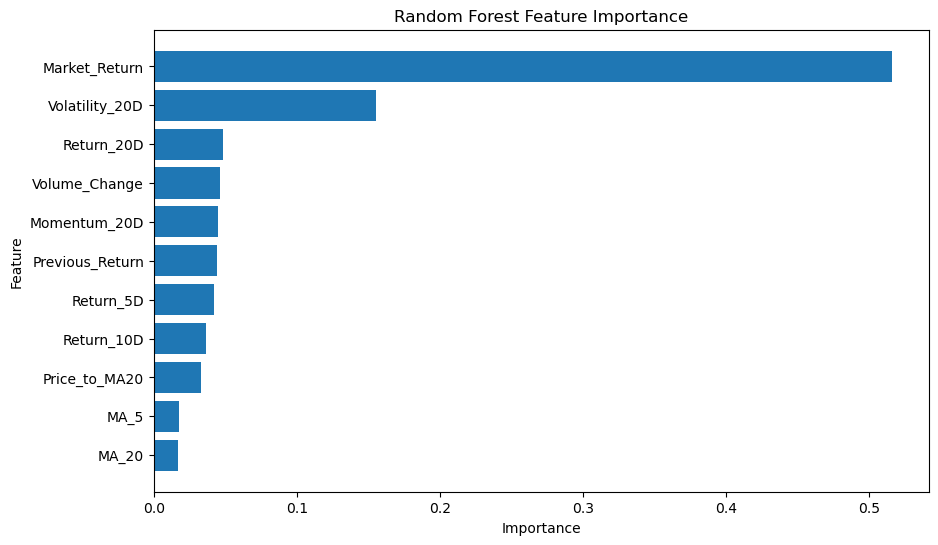

In [44]:
# plot Random Forest feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [45]:
# XGBoost feature importance

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
10,Market_Return,0.254686
4,Volatility_20D,0.188558
3,Return_20D,0.107264
8,Volume_Change,0.084288
9,Price_to_MA20,0.073062
2,Return_10D,0.068925
1,Return_5D,0.064056
5,MA_5,0.056370
0,Previous_Return,0.053007
6,MA_20,0.049783


In [46]:
# compare actual vs. predicted returns

comparison = pd.DataFrame({
    "Actual": y_test,
    "Linear Regression": linear_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions
})

comparison.head()

,Actual,Linear Regression,Random Forest,XGBoost
1763,0.002901,0.001723,0.000409,-0.000454
1811,0.020816,0.005383,0.000708,0.006695
1814,0.018359,0.000383,0.000409,0.000816
1846,-0.004332,0.002513,0.000708,0.005944
1854,0.011719,0.003146,0.000708,-0.003575


In [47]:
comparison.describe()

,Actual,Linear Regression,Random Forest,XGBoost
count,21190.000000,21190.000000,21190.000000,21190.000000
mean,0.000279,0.000456,0.000125,-0.000051
std,0.018971,0.003179,0.002445,0.003248
min,-0.269944,-0.276167,-0.078455,-0.039891
25%,-0.008261,-0.000998,0.000409,-0.001325
50%,0.000371,0.000140,0.000409,-0.000113
75%,0.008754,0.001540,0.000708,0.001205
max,0.961905,0.077106,0.088846,0.090303


In [48]:
# build neural network model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

neural_network = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1)
])

neural_network.compile(
    optimizer="adam",
    loss="mse"
)

neural_network.summary()

C:\Users\mwror\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# train neural network

history = neural_network.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0059 - val_loss: 7.8550e-04
Epoch 2/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0034 - val_loss: 5.0390e-04
Epoch 3/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0019 - val_loss: 4.1487e-04
Epoch 4/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0043 - val_loss: 5.1229e-04
Epoch 5/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0049 - val_loss: 3.5212e-04
Epoch 6/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.3701e-04 - val_loss: 3.3626e-04
Epoch 7/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0034 - val_loss: 3.7966e-04
Epoch 8/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.6447e-04 - val_loss: 3.2079e-04
Epoch 9/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.2148e-04 - val_loss: 3.2410e-04
Epoch 10/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.2720e-04 - val_loss: 3.1779e-04
Epoch 11/20
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0028 - val_loss: 3.1

In [50]:
# make neural network predictions

nn_predictions = neural_network.predict(
    X_test_scaled,
    verbose=0
).flatten()

print("Number of predictions:", len(nn_predictions))
print("First 5 predictions:")
print(nn_predictions[:5])

Number of predictions: 21190
First 5 predictions:
[ 0.00103293  0.00574524 -0.00248887  0.00201079  0.00048323]


In [51]:
# evaluate neural network

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

nn_mse = mean_squared_error(y_test, nn_predictions)
nn_rmse = np.sqrt(nn_mse)
nn_mae = mean_absolute_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

print("Neural Network Results")
print("----------------------")
print("MSE:", nn_mse)
print("RMSE:", nn_rmse)
print("MAE:", nn_mae)
print("R²:", nn_r2)

Neural Network Results
----------------------
MSE: 0.00039283430228692813
RMSE: 0.019820047989016782
MAE: 0.012193831699879091
R²: -0.09157378700809748


In [53]:
# final model comparison

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "MSE": [
        mean_squared_error(y_test, linear_predictions),
        mean_squared_error(y_test, rf_predictions),
        mean_squared_error(y_test, xgb_predictions),
        mean_squared_error(y_test, nn_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions)),
        np.sqrt(mean_squared_error(y_test, xgb_predictions)),
        np.sqrt(mean_squared_error(y_test, nn_predictions))
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, rf_predictions),
        mean_absolute_error(y_test, xgb_predictions),
        mean_absolute_error(y_test, nn_predictions)
    ],
    "R²": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, rf_predictions),
        r2_score(y_test, xgb_predictions),
        r2_score(y_test, nn_predictions)
    ]
})

results

,Model,MSE,RMSE,MAE,R²
0,Linear Regression,0.000353,0.018796,0.011963,0.018295
1,Random Forest,0.000373,0.019325,0.012033,-0.037713
2,XGBoost,0.000361,0.019005,0.011867,-0.003662
3,Neural Network,0.000393,0.019820,0.012194,-0.091574


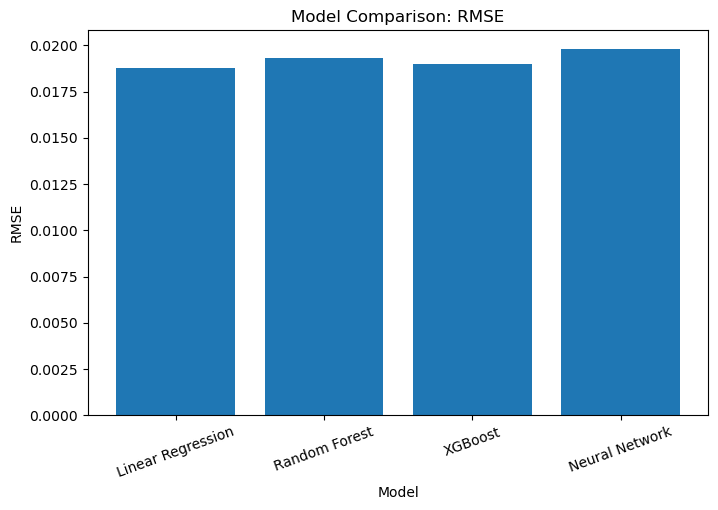

In [54]:
# visualize model performance

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Comparison: RMSE")
plt.xticks(rotation=20)

plt.show()

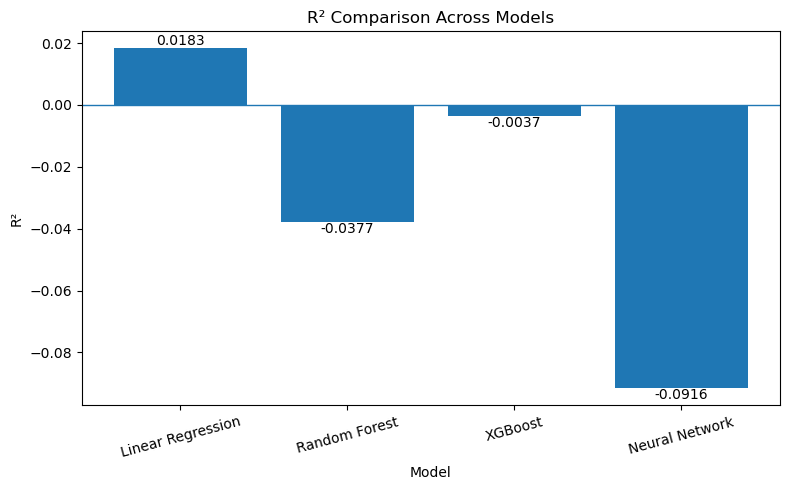

In [55]:
# R² comparison with values displayed

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(results["Model"], results["R²"])

plt.axhline(0, linewidth=1)

plt.title("R² Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("R²")

plt.xticks(rotation=15)

for bar, value in zip(bars, results["R²"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

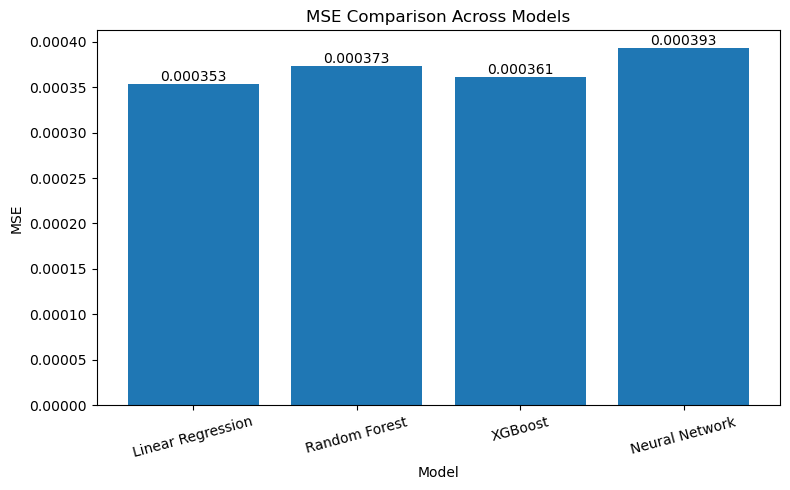

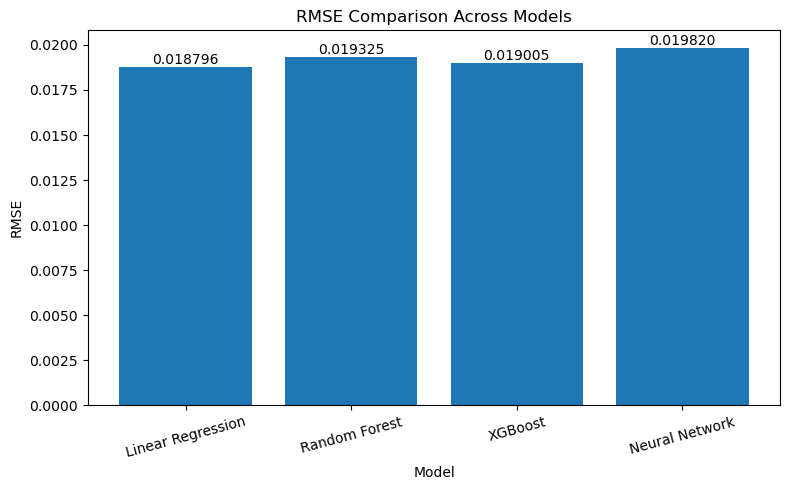

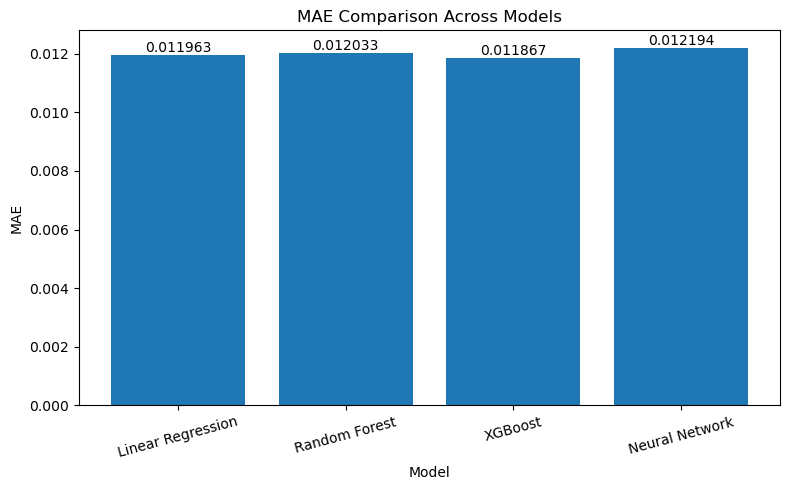

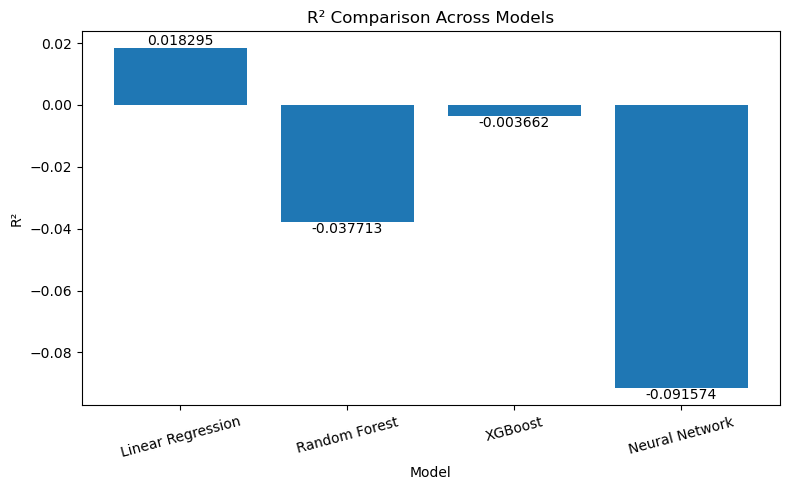

In [56]:
# model performance across all metrics

metrics = ["MSE", "RMSE", "MAE", "R²"]

for metric in metrics:

    plt.figure(figsize=(8, 5))

    bars = plt.bar(results["Model"], results[metric])

    plt.title(f"{metric} Comparison Across Models")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(rotation=15)

    for bar, value in zip(bars, results[metric]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.6f}",
            ha="center",
            va="bottom" if value >= 0 else "top"
        )

    plt.tight_layout()
    plt.show()

In [57]:
# actual vs. predicted returns

comparison = pd.DataFrame({
    "Actual": y_test,
    "Linear Regression": linear_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions,
    "Neural Network": nn_predictions
})

comparison.head()

,Actual,Linear Regression,Random Forest,XGBoost,Neural Network
1763,0.002901,0.001723,0.000409,-0.000454,0.001033
1811,0.020816,0.005383,0.000708,0.006695,0.005745
1814,0.018359,0.000383,0.000409,0.000816,-0.002489
1846,-0.004332,0.002513,0.000708,0.005944,0.002011
1854,0.011719,0.003146,0.000708,-0.003575,0.000483


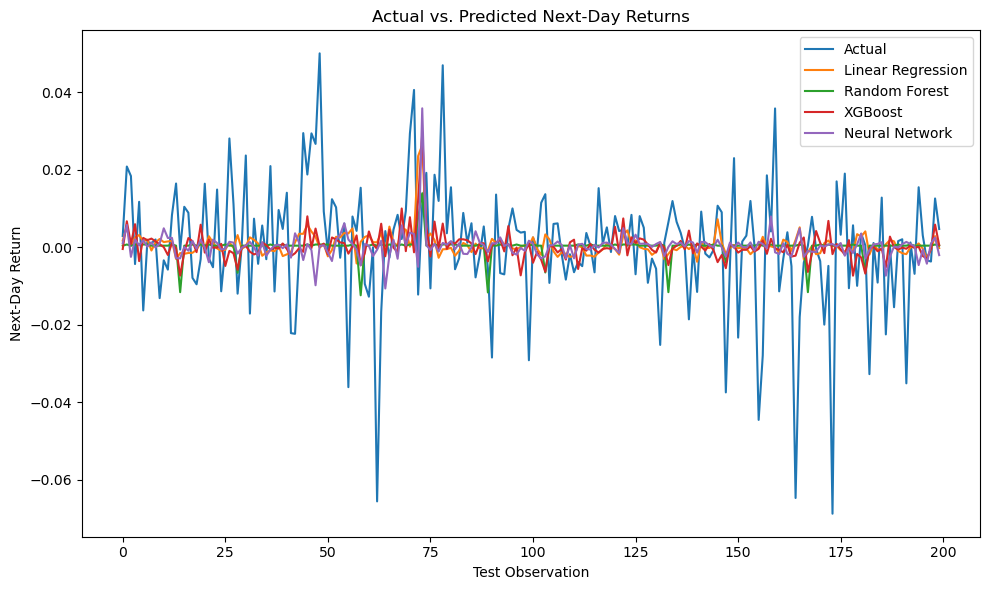

In [58]:
# plot actual vs. predicted returns

plt.figure(figsize=(10, 6))

plt.plot(
    comparison["Actual"].values[:200],
    label="Actual"
)

plt.plot(
    comparison["Linear Regression"].values[:200],
    label="Linear Regression"
)

plt.plot(
    comparison["Random Forest"].values[:200],
    label="Random Forest"
)

plt.plot(
    comparison["XGBoost"].values[:200],
    label="XGBoost"
)

plt.plot(
    comparison["Neural Network"].values[:200],
    label="Neural Network"
)

plt.title("Actual vs. Predicted Next-Day Returns")
plt.xlabel("Test Observation")
plt.ylabel("Next-Day Return")
plt.legend()

plt.tight_layout()
plt.show()

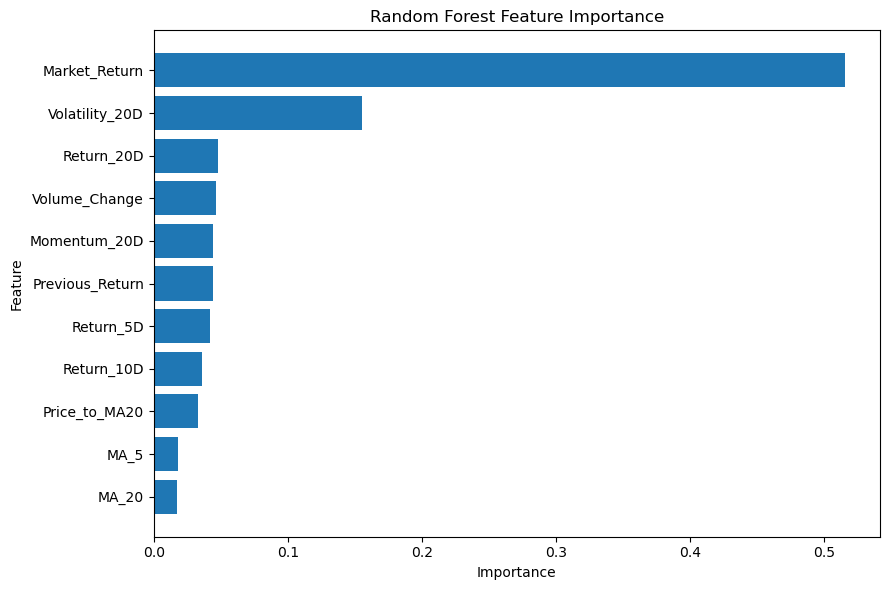

In [59]:
# random Forest feature importance

rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

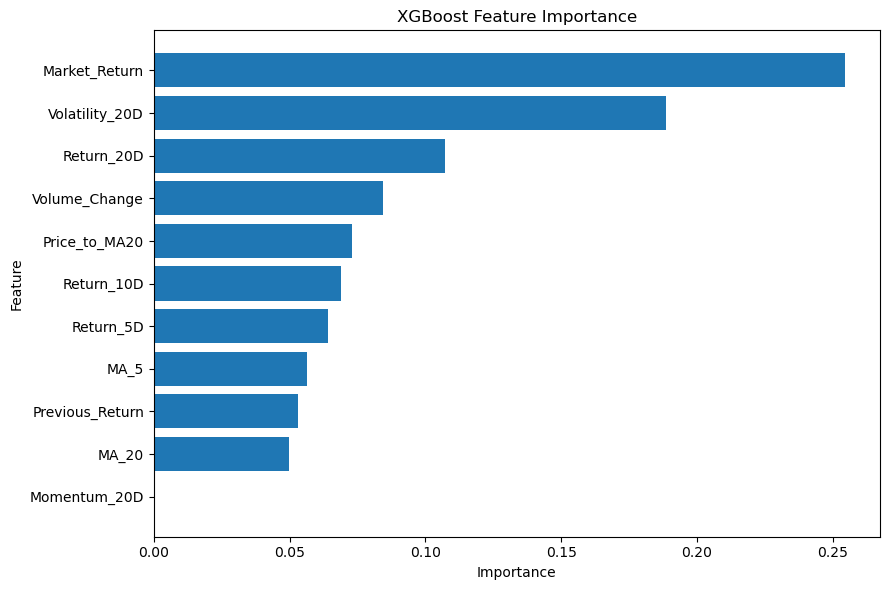

In [60]:
# XGBoost feature importance

xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [61]:
# prediction errors

comparison["Linear Regression Error"] = (
    comparison["Actual"] - comparison["Linear Regression"]
)

comparison["Random Forest Error"] = (
    comparison["Actual"] - comparison["Random Forest"]
)

comparison["XGBoost Error"] = (
    comparison["Actual"] - comparison["XGBoost"]
)

comparison["Neural Network Error"] = (
    comparison["Actual"] - comparison["Neural Network"]
)

comparison.head()

,Actual,Linear Regression,Random Forest,XGBoost,Neural Network,Linear Regression Error,Random Forest Error,XGBoost Error,Neural Network Error
1763,0.002901,0.001723,0.000409,-0.000454,0.001033,0.001178,0.002492,0.003355,0.001868
1811,0.020816,0.005383,0.000708,0.006695,0.005745,0.015433,0.020108,0.014121,0.015071
1814,0.018359,0.000383,0.000409,0.000816,-0.002489,0.017975,0.017950,0.017543,0.020848
1846,-0.004332,0.002513,0.000708,0.005944,0.002011,-0.006845,-0.005040,-0.010276,-0.006343
1854,0.011719,0.003146,0.000708,-0.003575,0.000483,0.008573,0.011011,0.015294,0.011236


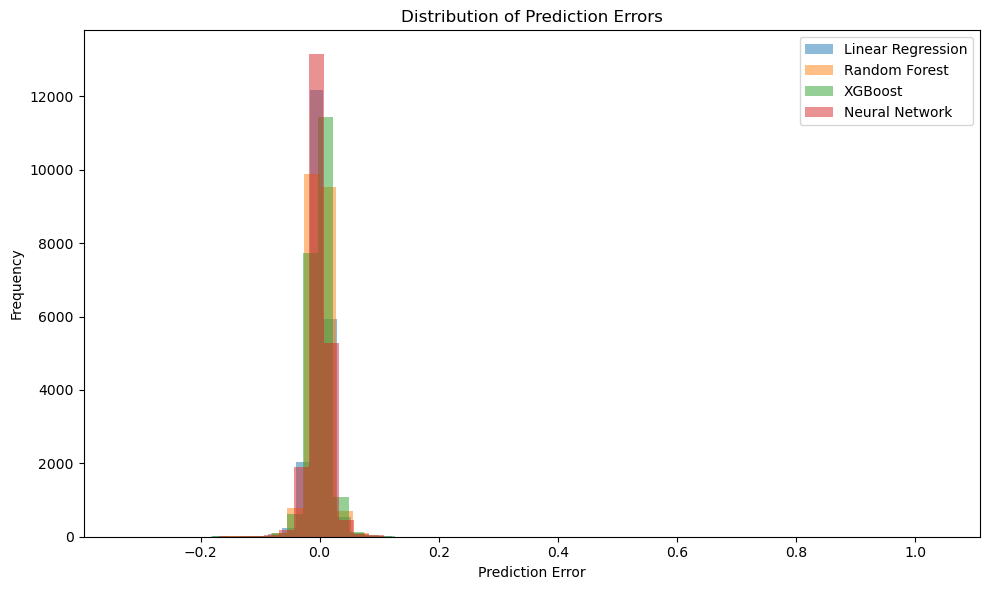

In [62]:
# residual comparison

plt.figure(figsize=(10, 6))

plt.hist(
    comparison["Linear Regression Error"],
    bins=50,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    comparison["Random Forest Error"],
    bins=50,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    comparison["XGBoost Error"],
    bins=50,
    alpha=0.5,
    label="XGBoost"
)

plt.hist(
    comparison["Neural Network Error"],
    bins=50,
    alpha=0.5,
    label="Neural Network"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [63]:
# directional accuracy

actual_direction = comparison["Actual"] > 0

linear_direction = comparison["Linear Regression"] > 0
rf_direction = comparison["Random Forest"] > 0
xgb_direction = comparison["XGBoost"] > 0
nn_direction = comparison["Neural Network"] > 0

linear_accuracy = (actual_direction == linear_direction).mean()
rf_accuracy = (actual_direction == rf_direction).mean()
xgb_accuracy = (actual_direction == xgb_direction).mean()
nn_accuracy = (actual_direction == nn_direction).mean()

print("Directional Accuracy")
print("--------------------")
print(f"Linear Regression: {linear_accuracy:.4%}")
print(f"Random Forest: {rf_accuracy:.4%}")
print(f"XGBoost: {xgb_accuracy:.4%}")
print(f"Neural Network: {nn_accuracy:.4%}")

Directional Accuracy
--------------------
Linear Regression: 51.6234%
Random Forest: 51.4630%
XGBoost: 53.1194%
Neural Network: 50.5474%


In [64]:
# directional accuracy table

directional_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Directional Accuracy": [
        linear_accuracy,
        rf_accuracy,
        xgb_accuracy,
        nn_accuracy
    ]
})

directional_results

,Model,Directional Accuracy
0,Linear Regression,0.516234
1,Random Forest,0.514630
2,XGBoost,0.531194
3,Neural Network,0.505474


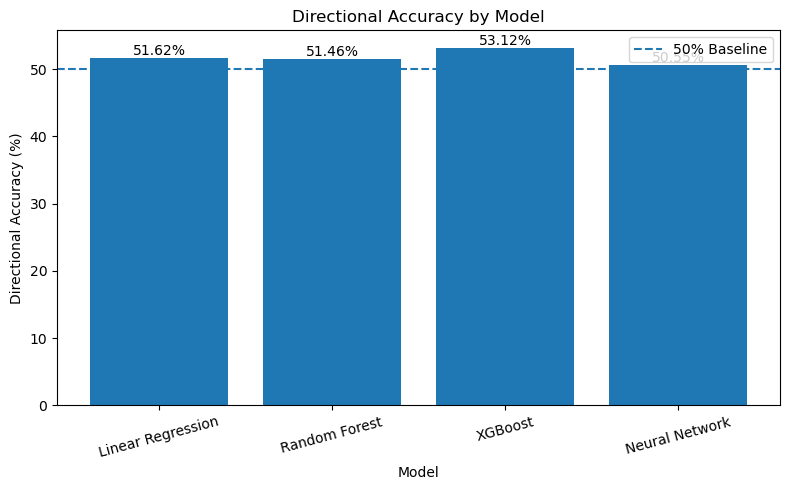

In [65]:
# plot directional accuracy

plt.figure(figsize=(8, 5))

bars = plt.bar(
    directional_results["Model"],
    directional_results["Directional Accuracy"] * 100
)

plt.axhline(
    50,
    linestyle="--",
    label="50% Baseline"
)

plt.title("Directional Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Directional Accuracy (%)")
plt.xticks(rotation=15)
plt.legend()

for bar, value in zip(
    bars,
    directional_results["Directional Accuracy"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

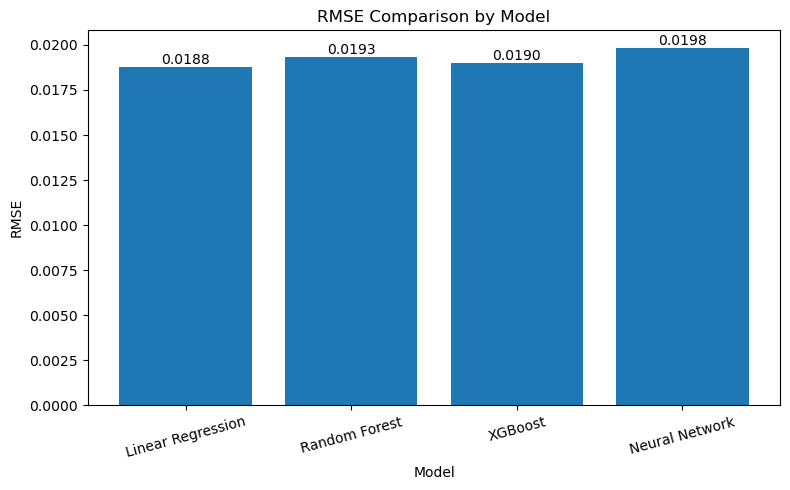

In [67]:
# RMSE comparison

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("RMSE Comparison by Model")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)

for bar, value in zip(bars, results["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

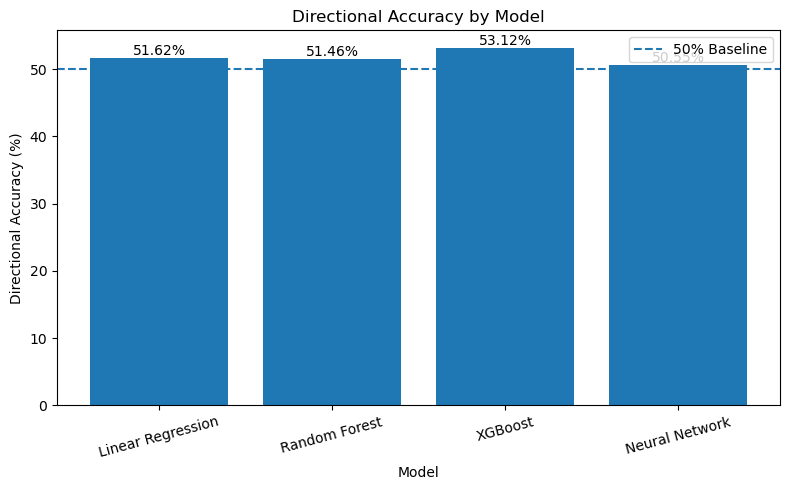

In [68]:
# directional accuracy comparison

plt.figure(figsize=(8, 5))

bars = plt.bar(
    directional_results["Model"],
    directional_results["Directional Accuracy"] * 100
)

plt.axhline(
    50,
    linestyle="--",
    label="50% Baseline"
)

plt.title("Directional Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Directional Accuracy (%)")
plt.xticks(rotation=15)
plt.legend()

for bar, value in zip(
    bars,
    directional_results["Directional Accuracy"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [69]:
from scipy.stats import binomtest

xgb_correct = (actual_direction == xgb_direction).sum()
xgb_total = len(actual_direction)

# binomial test against a 50% baseline
xgb_test = binomtest(
    xgb_correct,
    n=xgb_total,
    p=0.50,
    alternative="greater"
)

print("XGBoost Directional Accuracy Test")
print("---------------------------------")
print("Correct predictions:", xgb_correct)
print("Total predictions:", xgb_total)
print("Directional accuracy:", f"{xgb_correct / xgb_total:.4%}")
print("P-value:", xgb_test.pvalue)

XGBoost Directional Accuracy Test
---------------------------------
Correct predictions: 11256
Total predictions: 21190
Directional accuracy: 53.1194%
P-value: 5.543995789609521e-20


In [70]:
models_direction = {
    "Linear Regression": linear_direction,
    "Random Forest": rf_direction,
    "XGBoost": xgb_direction,
    "Neural Network": nn_direction
}

significance_results = []

for model, predictions in models_direction.items():

    correct = (actual_direction == predictions).sum()
    total = len(actual_direction)

    test = binomtest(
        correct,
        n=total,
        p=0.50,
        alternative="greater"
    )

    significance_results.append({
        "Model": model,
        "Correct Predictions": correct,
        "Total Predictions": total,
        "Directional Accuracy": correct / total,
        "P-value": test.pvalue
    })

significance_results = pd.DataFrame(significance_results)

significance_results

,Model,Correct Predictions,Total Predictions,Directional Accuracy,P-value
0,Linear Regression,10939,21190,0.516234,1.180130e-06
1,Random Forest,10905,21190,0.514630,1.056522e-05
2,XGBoost,11256,21190,0.531194,5.543996e-20
3,Neural Network,10711,21190,0.505474,5.626784e-02


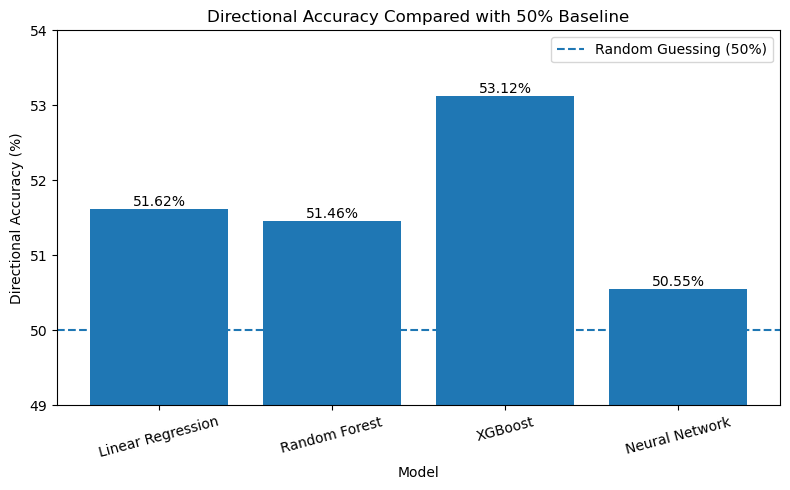

In [71]:
# directional accuracy compared with 50% baseline

plt.figure(figsize=(8, 5))

accuracy_percent = significance_results["Directional Accuracy"] * 100

bars = plt.bar(
    significance_results["Model"],
    accuracy_percent
)

plt.axhline(
    50,
    linestyle="--",
    label="Random Guessing (50%)"
)

plt.title("Directional Accuracy Compared with 50% Baseline")
plt.xlabel("Model")
plt.ylabel("Directional Accuracy (%)")
plt.xticks(rotation=15)
plt.legend()

for bar, value in zip(bars, accuracy_percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(49, 54)

plt.tight_layout()
plt.show()

In [72]:
# mcNemar's test to compare directional predictions
from statsmodels.stats.contingency_tables import mcnemar
def compare_directional_accuracy(model1, model2, name1, name2):
    
    correct1 = (actual_direction == model1)
    correct2 = (actual_direction == model2)

# [[both correct, model1 correct/model2 wrong],
#  [model1 wrong/model2 correct, both wrong]]
    table = pd.crosstab(correct1, correct2)
    table = table.reindex(
        index=[False, True],
        columns=[False, True],
        fill_value=0
    )

    test = mcnemar(table, exact=False, correction=True)

    print(f"{name1} vs. {name2}")
    print("-----------------------------")
    print(table)
    print(f"McNemar p-value: {test.pvalue:.6g}")
    print()


compare_directional_accuracy(
    xgb_direction,
    linear_direction,
    "XGBoost",
    "Linear Regression"
)

compare_directional_accuracy(
    xgb_direction,
    rf_direction,
    "XGBoost",
    "Random Forest"
)

compare_directional_accuracy(
    xgb_direction,
    nn_direction,
    "XGBoost",
    "Neural Network"
)

XGBoost vs. Linear Regression
-----------------------------
col_0  False  True 
row_0              
False   5087   4847
True    5164   6092
McNemar p-value: 0.00158712

XGBoost vs. Random Forest
-----------------------------
col_0  False  True 
row_0              
False   5013   4921
True    5272   5984
McNemar p-value: 0.000526878

XGBoost vs. Neural Network
-----------------------------
col_0  False  True 
row_0              
False   5559   4375
True    4920   6336
McNemar p-value: 1.67565e-08



In [74]:
# baseline predict 0% return for every stock-day

baseline_predictions = np.zeros(len(y_test))

baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline Results")
print("----------------------")
print("MSE:", baseline_mse)
print("RMSE:", baseline_rmse)
print("MAE:", baseline_mae)
print("R²:", baseline_r2)

Baseline Results
----------------------
MSE: 0.0003599564316942412
RMSE: 0.018972517800604147
MAE: 0.011947351973031766
R²: -0.00021562021183818558


In [75]:
# baseline directional accuracy

baseline_directional_accuracy = (y_test > 0).mean()

print("Baseline Directional Accuracy:",
      baseline_directional_accuracy)

Baseline Directional Accuracy: 0.5091552619159981


In [77]:
# compare all models with the 0% baseline

baseline_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "MSE": [
        baseline_mse,
        0.0003534578929820499,
        0.000373,
        0.000361,
        0.000393
    ],
    "RMSE": [
        baseline_rmse,
        0.018796,
        0.019325,
        0.019005,
        0.019820
    ],
    "MAE": [
        baseline_mae,
        0.011963,
        0.012033,
        0.011867,
        0.012194
    ],
    "R²": [
        baseline_r2,
        0.018295,
        -0.037713,
        -0.003662,
        -0.091574
    ],
    "Directional Accuracy": [
        baseline_directional_accuracy,
        0.516234,
        0.514630,
        0.531194,
        0.505474
    ]
})

baseline_results

,Model,MSE,RMSE,MAE,R²,Directional Accuracy
0,Baseline,0.000360,0.018973,0.011947,-0.000216,0.509155
1,Linear Regression,0.000353,0.018796,0.011963,0.018295,0.516234
2,Random Forest,0.000373,0.019325,0.012033,-0.037713,0.514630
3,XGBoost,0.000361,0.019005,0.011867,-0.003662,0.531194
4,Neural Network,0.000393,0.019820,0.012194,-0.091574,0.505474


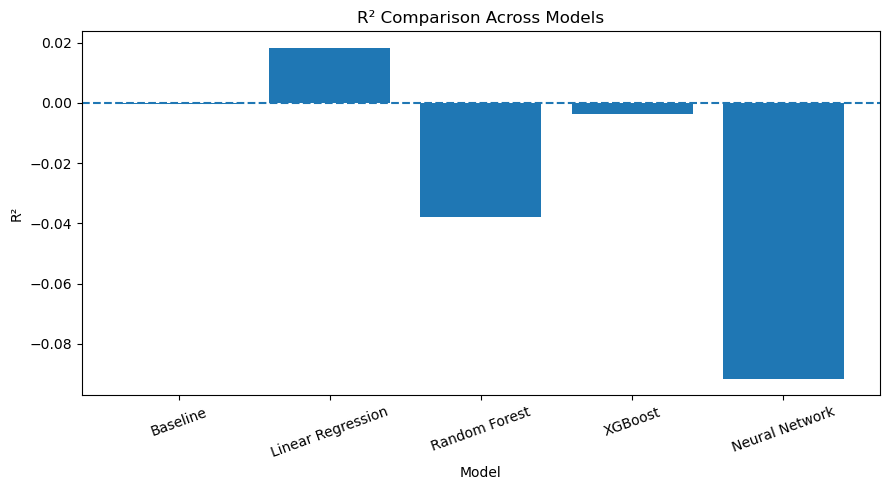

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    baseline_results["Model"],
    baseline_results["R²"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("R² Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("R²")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

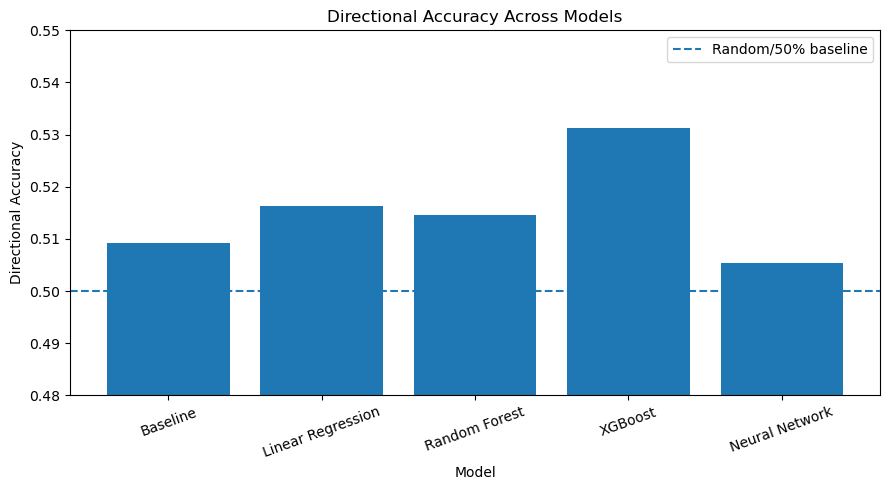

In [79]:
plt.figure(figsize=(9, 5))

plt.bar(
    baseline_results["Model"],
    baseline_results["Directional Accuracy"]
)

plt.axhline(
    0.50,
    linestyle="--",
    label="Random/50% baseline"
)

plt.title("Directional Accuracy Across Models")
plt.xlabel("Model")
plt.ylabel("Directional Accuracy")

plt.ylim(0.48, 0.55)
plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()
plt.show()

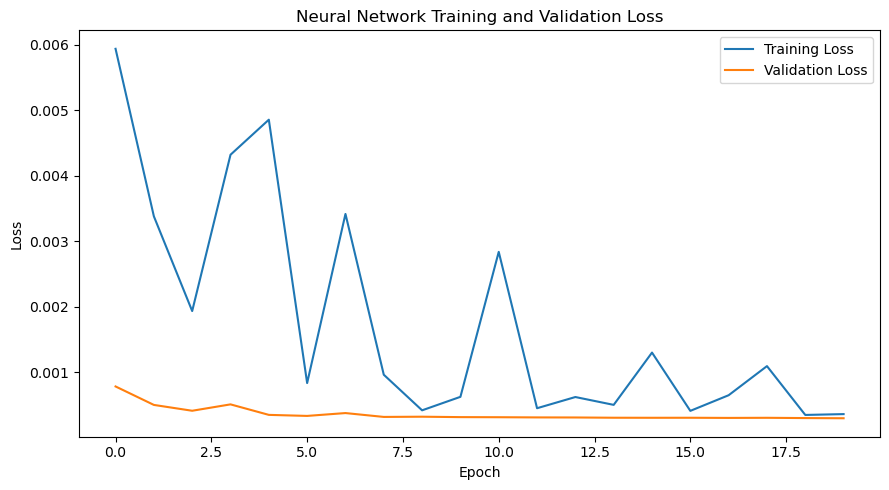

In [80]:
plt.figure(figsize=(9, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Neural Network Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [81]:
print("Actual returns:")
print(pd.Series(y_test).describe())

print("\nNeural Network predictions:")
print(pd.Series(nn_predictions.flatten()).describe())

Actual returns:
count    21190.000000
mean         0.000279
std          0.018971
min         -0.269944
25%         -0.008261
50%          0.000371
75%          0.008754
max          0.961905
Name: Next_Day_Return, dtype: float64

Neural Network predictions:
count    21190.000000
mean        -0.000024
std          0.006313
min         -0.448176
25%         -0.001058
50%          0.000279
75%          0.001122
max          0.063883
dtype: float64


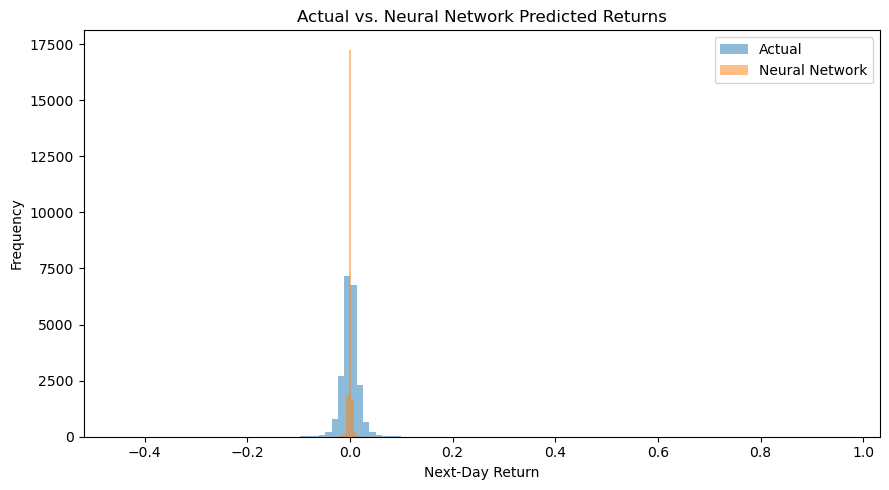

In [82]:
plt.figure(figsize=(9, 5))

plt.hist(y_test, bins=100, alpha=0.5, label="Actual")
plt.hist(nn_predictions.flatten(), bins=100, alpha=0.5, label="Neural Network")

plt.title("Actual vs. Neural Network Predicted Returns")
plt.xlabel("Next-Day Return")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [89]:
nn_comparison = pd.DataFrame({
    "Actual": y_test,
    "NN_Prediction": nn_predictions.flatten()
})

print("Most negative NN predictions:")
print(
    nn_comparison.sort_values("NN_Prediction").head(10)
)

print("\nMost positive NN predictions:")
print(
    nn_comparison.sort_values("NN_Prediction", ascending=False).head(10)
)

Most negative NN predictions:
          Actual  NN_Prediction
987420 -0.012658      -0.448176
987390 -0.238989      -0.377153
987264  0.002857      -0.281883
987336  0.000000      -0.272810
987314 -0.000953      -0.264969
987586 -0.058350      -0.148593
948746 -0.013981      -0.089302
948544  0.008204      -0.085381
948545 -0.016141      -0.071525
987441  0.158571      -0.067524

Most positive NN predictions:
           Actual  NN_Prediction
987705  -0.055046       0.063883
1156151 -0.047534       0.055633
1266974 -0.012645       0.049396
558762  -0.029166       0.039483
144028  -0.007385       0.038890
1150698  0.018588       0.038106
948663  -0.005457       0.037525
1150776 -0.025887       0.036729
6905     0.010886       0.035824
143800   0.011264       0.035223


In [90]:
#check NN predictions
print("Predictions below -10%:",
      (nn_comparison["NN_Prediction"] < -0.10).sum())

print("Predictions above +10%:",
      (nn_comparison["NN_Prediction"] > 0.10).sum())

print("Predictions between -1% and +1%:",
      (
          (nn_comparison["NN_Prediction"] >= -0.01) &
          (nn_comparison["NN_Prediction"] <= 0.01)
      ).sum())

Predictions below -10%: 6
Predictions above +10%: 0
Predictions between -1% and +1%: 20906


In [91]:
extreme_nn = comparison.copy()

extreme_nn["Abs_NN_Prediction"] = (
    extreme_nn["Neural Network"].abs()
)

extreme_nn = extreme_nn.sort_values(
    "Abs_NN_Prediction",
    ascending=False
)

print(extreme_nn.head(20))

           Actual  Linear Regression  Random Forest   XGBoost  Neural Network  \
987420  -0.012658          -0.021695       0.048009  0.003269       -0.448176   
987390  -0.238989          -0.276167       0.088846  0.072542       -0.377153   
987264   0.002857          -0.021870       0.000708  0.001280       -0.281883   
987336   0.000000          -0.006589       0.000409 -0.001136       -0.272810   
987314  -0.000953          -0.008520       0.000409 -0.001093       -0.264969   
987586  -0.058350           0.048044      -0.031214 -0.009590       -0.148593   
948746  -0.013981           0.002448       0.000409 -0.003337       -0.089302   
948544   0.008204           0.003358       0.000409  0.000600       -0.085381   
948545  -0.016141           0.002797       0.000708 -0.001294       -0.071525   
987441   0.158571          -0.061674       0.075566  0.003349       -0.067524   
948272   0.001314           0.000021       0.000409  0.000808       -0.064902   
948156   0.029163           

In [92]:
nn_debug = model_data.loc[
    y_test.index if hasattr(y_test, "index") else X_test.index
].copy()

nn_debug["Actual"] = y_test
nn_debug["NN_Prediction"] = nn_predictions.flatten()

nn_debug["Prediction_Error"] = (
    nn_debug["NN_Prediction"] - nn_debug["Actual"]
)

nn_debug["Abs_Error"] = (
    nn_debug["Prediction_Error"].abs()
)

print(
    nn_debug.sort_values(
        "Abs_Error",
        ascending=False
    )[[
        "Date",
        "Ticker",
        "Actual",
        "NN_Prediction",
        "Prediction_Error"
    ]].head(20)
)

              Date Ticker    Actual  NN_Prediction  Prediction_Error
987581  2024-09-23   PARA  0.961905      -0.028627         -0.990532
987420  2024-02-01   PARA -0.012658      -0.448176         -0.435518
987264  2023-06-20   PARA  0.002857      -0.281883         -0.284740
987336  2023-10-02   PARA  0.000000      -0.272810         -0.272810
443350  2024-05-08   EPAM -0.269944      -0.000482          0.269462
987314  2023-08-30   PARA -0.000953      -0.264969         -0.264016
1383504 2025-07-23    WST  0.227839      -0.000757         -0.228595
987441  2024-03-04   PARA  0.158571      -0.067524         -0.226095
841014  2024-02-01   META  0.203176      -0.000580         -0.203756
1418145 2023-05-04   ZION  0.192172      -0.005533         -0.197706
771207  2025-07-23    LKQ -0.178192       0.000172          0.178365
176096  2023-05-04    BIO -0.167247       0.008897          0.176143
61365   2024-03-04    ALB -0.178679      -0.002654          0.176024
387682  2025-07-23    DOW -0.17451

In [93]:
# check para since NN is weirdly off
para_extreme_dates = [
    "2023-06-20",
    "2023-08-30",
    "2023-10-02",
    "2024-02-01",
    "2024-03-04",
    "2024-09-23"
]

para_check = model_data[
    (model_data["Ticker"] == "PARA") &
    (model_data["Date"].isin(para_extreme_dates))
].copy()

para_check

C:\Users\mwror\AppData\Local\Temp\ipykernel_37484\852992026.py:13: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  (model_data["Date"].isin(para_extreme_dates))


,Date,Ticker,Previous_Return,Return_5D,Return_10D,Return_20D,Volatility_20D,MA_5,MA_20,Momentum_20D,Volume_Change,Price_to_MA20,Market_Return,Next_Day_Return
987264,2023-06-20,PARA,0.001440,0.003824,0.004785,-0.002849,0.007043,104050.0,104622.5,-0.002849,1.000000,1.003608,-0.004735,0.002857
987314,2023-08-30,PARA,0.000952,-0.001903,0.000000,0.000954,0.000939,105040.0,104957.5,0.000954,-1.000000,0.999452,0.003833,-0.000953
987336,2023-10-02,PARA,0.000000,0.000473,0.000000,0.007626,0.001138,105660.0,105477.5,0.007626,0.000000,1.002109,0.000079,0.000000
987420,2024-02-01,PARA,-0.012346,-0.018634,-0.076023,-0.042424,0.145128,15956.0,17929.0,-0.042424,4.500000,0.881254,0.012494,-0.012658
987441,2024-03-04,PARA,-0.013870,-0.067909,-0.448819,-0.551282,0.087505,7098.0,11030.5,-0.551282,0.222222,0.634604,-0.001193,0.158571
987581,2024-09-23,PARA,0.975694,0.150685,0.063291,-0.305785,0.241388,800.8,855.7,-0.305785,-0.974877,0.981652,0.002809,0.961905


In [88]:
# prediction errors

comparison["Linear Error"] = (
    comparison["Linear Regression"] - comparison["Actual"]
)

comparison["Random Forest Error"] = (
    comparison["Random Forest"] - comparison["Actual"]
)

comparison["XGBoost Error"] = (
    comparison["XGBoost"] - comparison["Actual"]
)

comparison["Neural Network Error"] = (
    comparison["Neural Network"] - comparison["Actual"]
)

comparison[
    [
        "Linear Error",
        "Random Forest Error",
        "XGBoost Error",
        "Neural Network Error"
    ]
].describe()

,Linear Error,Random Forest Error,XGBoost Error,Neural Network Error
count,21190.000000,21190.000000,21190.000000,21190.000000
mean,0.000177,-0.000154,-0.000329,-0.000303
std,0.018796,0.019325,0.019003,0.019818
min,-0.884799,-1.040359,-0.975254,-0.990532
25%,-0.008493,-0.008699,-0.008832,-0.008732
50%,-0.000240,-0.000227,-0.000369,-0.000281
75%,0.008495,0.008415,0.008066,0.008421
max,0.271234,0.327834,0.311531,0.269462
